In [6]:
import os 
from pathlib import Path
import numpy as np
import glob
os.chdir(Path('/home/globc/garcia/'))

from scenarIA.src.utils.plotutils import plot_mean_std_simulations
from scenarIA.src.utils.settings import DATASET_DIR, GRAPHS_DIR


In [7]:
colors_dict = {'historical':'k',
               'ssp119': 'orange',
              'ssp126': 'green', 
              'ssp245': 'b', 
              'ssp370':'r', 
              'ssp585': 'mediumorchid'}
labels = ['historical', 'ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
vmin = {'tas': 285, 'pr': 2.75}
vmax = {'tas': 293, 'pr': 3.25}

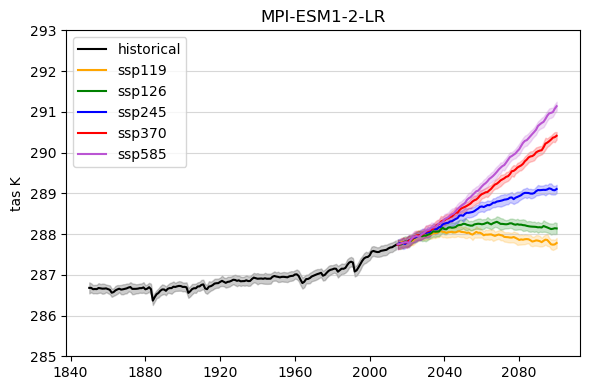

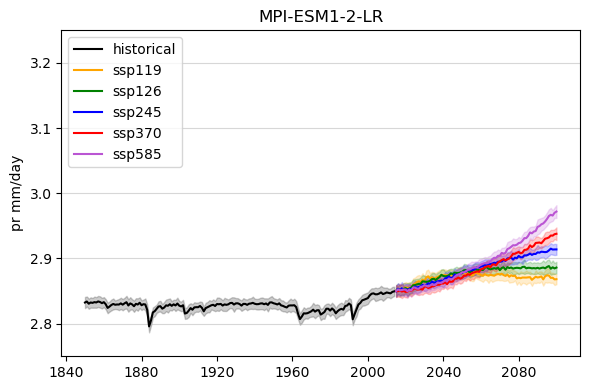

In [3]:

root_dir = DATASET_DIR / 'MPI-ESM1-2-LR/annual/'
files_dict = {}
for simu in labels:
    files_dict[simu] = root_dir / f'outputs_{simu}.nc'

for var in ['tas', 'pr']:
    plot_mean_std_simulations(files_dict,
                              var_name=var,
                              colors_dict = colors_dict,
                              title='MPI-ESM1-2-LR',
                              vmin=vmin[var],
                              vmax=vmax[var],
                              save_path=root_dir / f'MPI-ESM1-2-LR_{var}_temporal_evolution.png'
                              )

In [8]:
labels = ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
colors_dict = {'historical':'k',
              'ssp126': 'green', 
              'ssp245': 'b', 
              'ssp370':'r', 
              'ssp585': 'mediumorchid'}
root_dir = Path('/scratch/globc/garcia/common_data/CNRM-CM6-1/')


In [9]:
files_dict = {}

for var in ['tas', 'pr']:

    for exp in labels:
        if exp.startswith('ssp'):
            exp_paths = np.sort(glob.glob(str(f'/scratch/globc/garcia/common_data/CNRM-CM6-1/{exp}/{var}*reformat*.nc')))
        else:   
            exp_paths = glob.glob(str(f'/scratch/globc/garcia/common_data/CNRM-CM6-1/{exp}/{var}*185001-201412.nc'))
        files_dict[exp] = exp_paths

    plot_mean_std_simulations(files_dict,
                              var_name = var,
                              colors_dict = colors_dict,
                              time_res = 'm',
                              title='CNRM-CM6-1',
                              vmin=vmin[var],
                              vmax=vmax[var],
                              save_path=GRAPHS_DIR / f'tests/CNRM-CM6-1_Amon_{var}_temporal_evolution.png'
                              )

KeyboardInterrupt: 

<Figure size 600x400 with 0 Axes>

In [ ]:
root_path = '/gpfs-calypso/scratch/globc/garcia/scenarIA/rawdata/MPI-ESM1-2-LR/mon/'
files_dict = {}

for var in ['tas', 'pr']:

    for exp in labels:
        exp_paths = glob.glob(root_path + f'{exp}/{var}_Amon_MPI-ESM1-2-LR_{exp}_r1i1p1f1_gn_*.nc')
        files_dict[exp] = exp_paths
    print(files_dict)

    plot_mean_std_simulations(files_dict,
                              var_name = var,
                              colors_dict = colors_dict,
                              time_res = 'm',
                              title='MPI-ESM1-2-LR (Amon)',
                              vmin=vmin[var],
                              vmax=vmax[var],
                              save_path=GRAPHS_DIR / f'tests/MPI-ESM1-2-LR_Amon_{var}_temporal_evolution.png'
                              )